# FIFA Dataset Visual EDA

This notebook focuses on chart-based exploratory analysis for the cleaned FIFA dataset.

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  # pyright: ignore[reportMissingModuleSource]
import seaborn as sns  # pyright: ignore[reportMissingModuleSource]

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120

In [2]:
def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'ML').exists():
            return candidate
    raise FileNotFoundError('Could not locate repository root from current notebook path.')

repo_root = find_repo_root(Path.cwd())
players_clean_path = repo_root / 'ML' / 'data' / 'processed' / 'players_clean.csv'
model_ready_path = repo_root / 'ML' / 'data' / 'features' / 'model_ready.csv'
figures_dir = repo_root / 'ML' / 'data' / 'processed' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

players_clean = pd.read_csv(players_clean_path)
model_ready = pd.read_csv(model_ready_path)

print('players_clean:', players_clean.shape)
print('model_ready:', model_ready.shape)
print('figures_dir:', figures_dir)

players_clean: (20621, 15)
model_ready: (20621, 18)
figures_dir: /home/adham/Desktop/DEPI-ML-PROJECT/ML/data/processed/figures


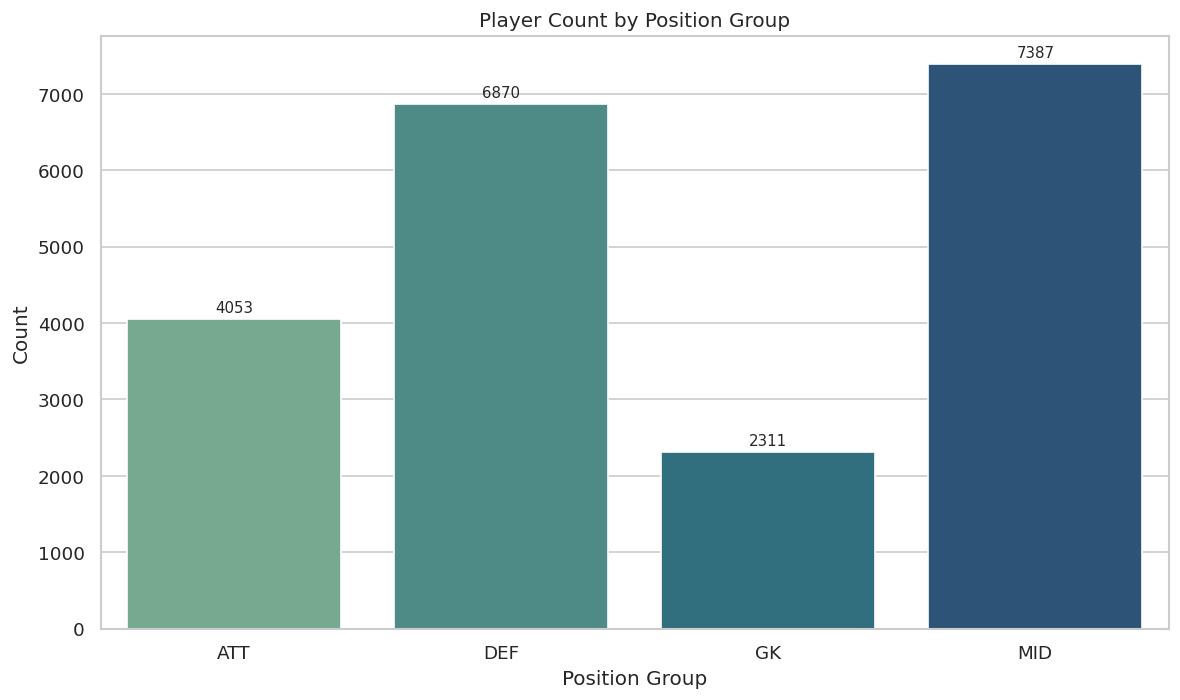

Saved: /home/adham/Desktop/DEPI-ML-PROJECT/ML/data/processed/figures/position_group_counts.png


In [8]:
position_counts = players_clean['position_group'].value_counts().sort_index()
position_count_df = pd.DataFrame(
    {
        'position_group': position_counts.index,
        'count': position_counts.values,
    }
)
ax = sns.barplot(
    data=position_count_df,
    x='position_group',
    y='count',
    hue='position_group',
    palette='crest',
    legend=False,
)
ax.set_title('Player Count by Position Group')
ax.set_xlabel('Position Group')
ax.set_ylabel('Count')
for i, value in enumerate(position_counts.values):
    ax.text(i, value + 50, f'{value}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
output_path = figures_dir / 'position_group_counts.png'
plt.savefig(output_path, bbox_inches='tight')
plt.show()
print('Saved:', output_path)

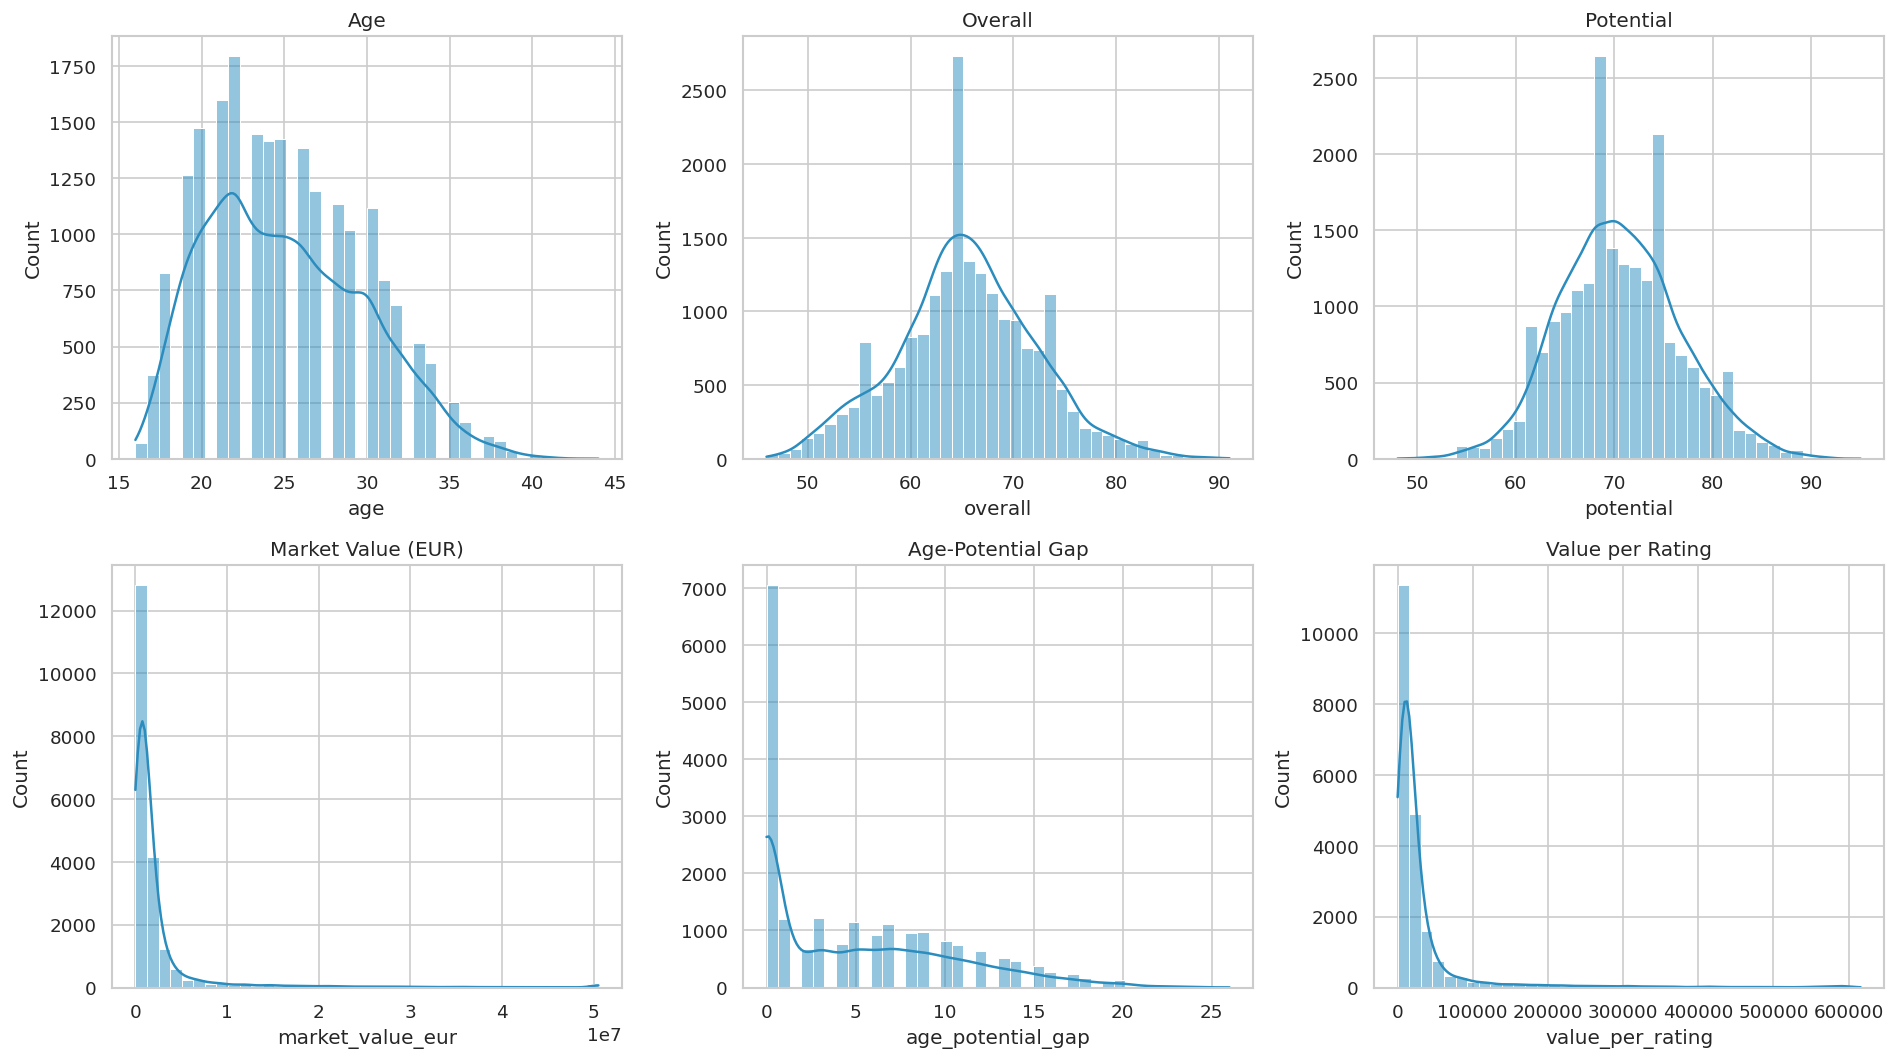

Saved: /home/adham/Desktop/DEPI-ML-PROJECT/ML/data/processed/figures/numeric_distributions.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_columns = [
    ('age', 'Age'),
    ('overall', 'Overall'),
    ('potential', 'Potential'),
    ('market_value_eur', 'Market Value (EUR)'),
    ('age_potential_gap', 'Age-Potential Gap'),
    ('value_per_rating', 'Value per Rating'),
]

for ax, (col, title) in zip(axes.flatten(), plot_columns):
    sns.histplot(players_clean[col], kde=True, bins=40, ax=ax, color='#2b8cbe')
    ax.set_title(title)

plt.tight_layout()
output_path = figures_dir / 'numeric_distributions.png'
plt.savefig(output_path, bbox_inches='tight')
plt.show()
print('Saved:', output_path)

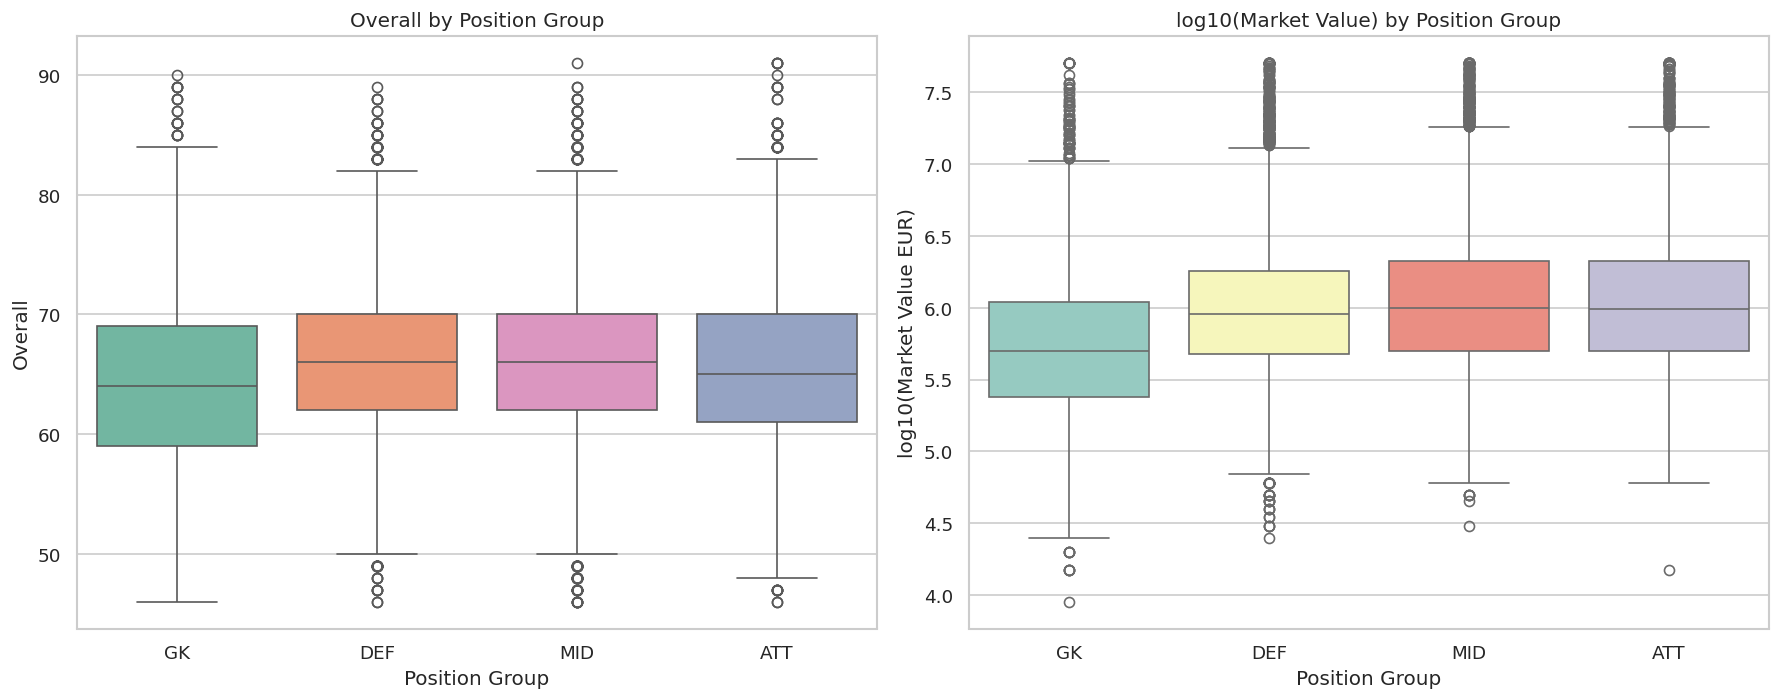

Saved: /home/adham/Desktop/DEPI-ML-PROJECT/ML/data/processed/figures/boxplots_by_position.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(
    data=players_clean,
    x='position_group',
    y='overall',
    hue='position_group',
    order=['GK', 'DEF', 'MID', 'ATT'],
    ax=axes[0],
    palette='Set2',
    dodge=False,
    legend=False,
)
axes[0].set_title('Overall by Position Group')
axes[0].set_xlabel('Position Group')
axes[0].set_ylabel('Overall')

plot_df = players_clean.copy()
plot_df['market_value_log10'] = np.log10(plot_df['market_value_eur'])
sns.boxplot(
    data=plot_df,
    x='position_group',
    y='market_value_log10',
    hue='position_group',
    order=['GK', 'DEF', 'MID', 'ATT'],
    ax=axes[1],
    palette='Set3',
    dodge=False,
    legend=False,
)
axes[1].set_title('log10(Market Value) by Position Group')
axes[1].set_xlabel('Position Group')
axes[1].set_ylabel('log10(Market Value EUR)')

plt.tight_layout()
output_path = figures_dir / 'boxplots_by_position.png'
plt.savefig(output_path, bbox_inches='tight')
plt.show()
print('Saved:', output_path)

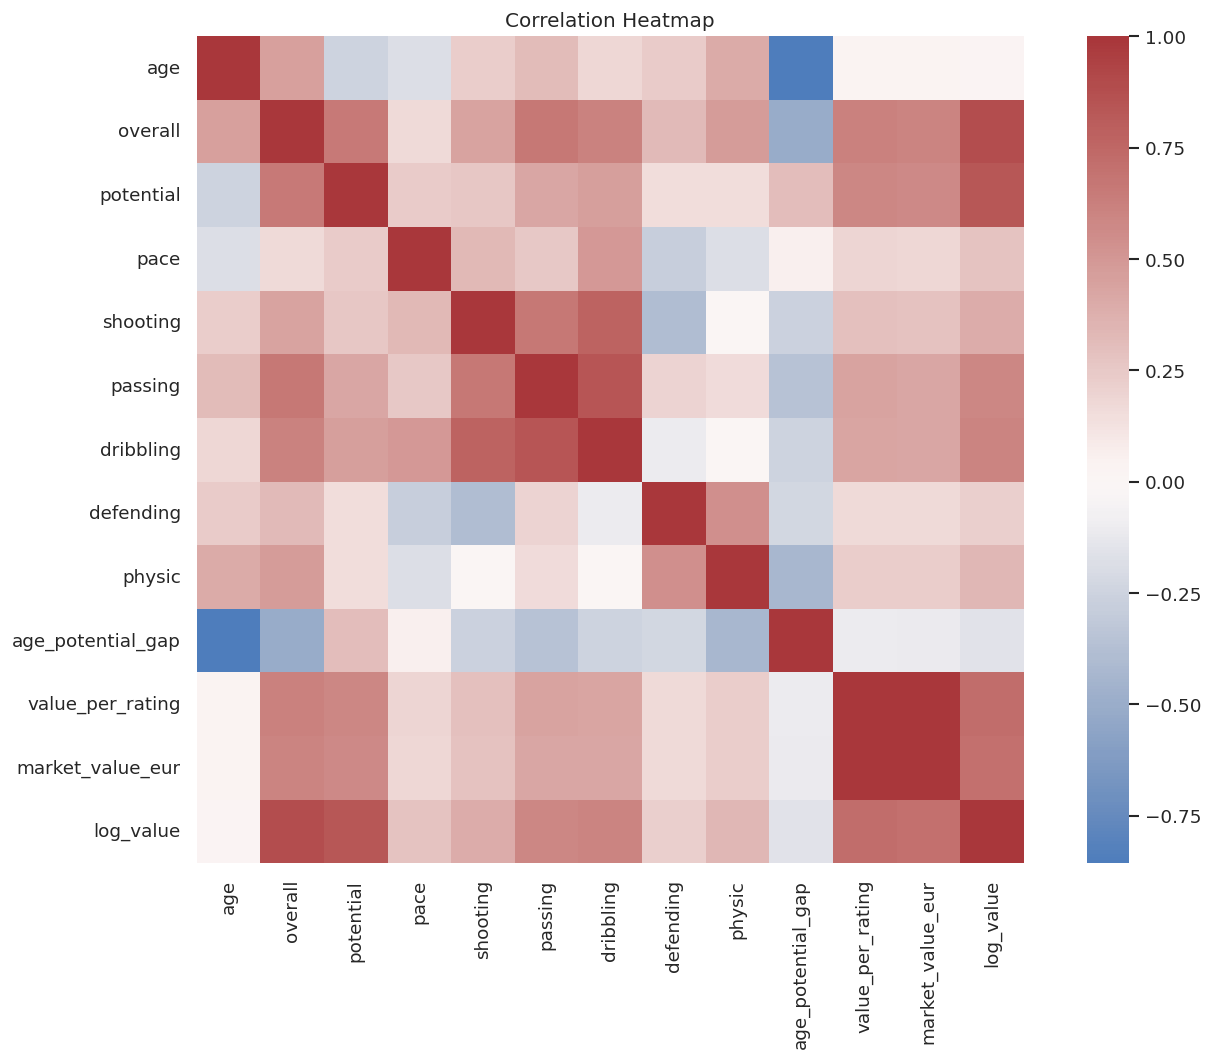

Saved: /home/adham/Desktop/DEPI-ML-PROJECT/ML/data/processed/figures/correlation_heatmap.png


In [6]:
corr_features = [
    'age',
    'overall',
    'potential',
    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic',
    'age_potential_gap',
    'value_per_rating',
    'market_value_eur',
    'log_value',
]
corr_df = model_ready[corr_features].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(corr_df, cmap='vlag', center=0, annot=False, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
output_path = figures_dir / 'correlation_heatmap.png'
plt.savefig(output_path, bbox_inches='tight')
plt.show()
print('Saved:', output_path)

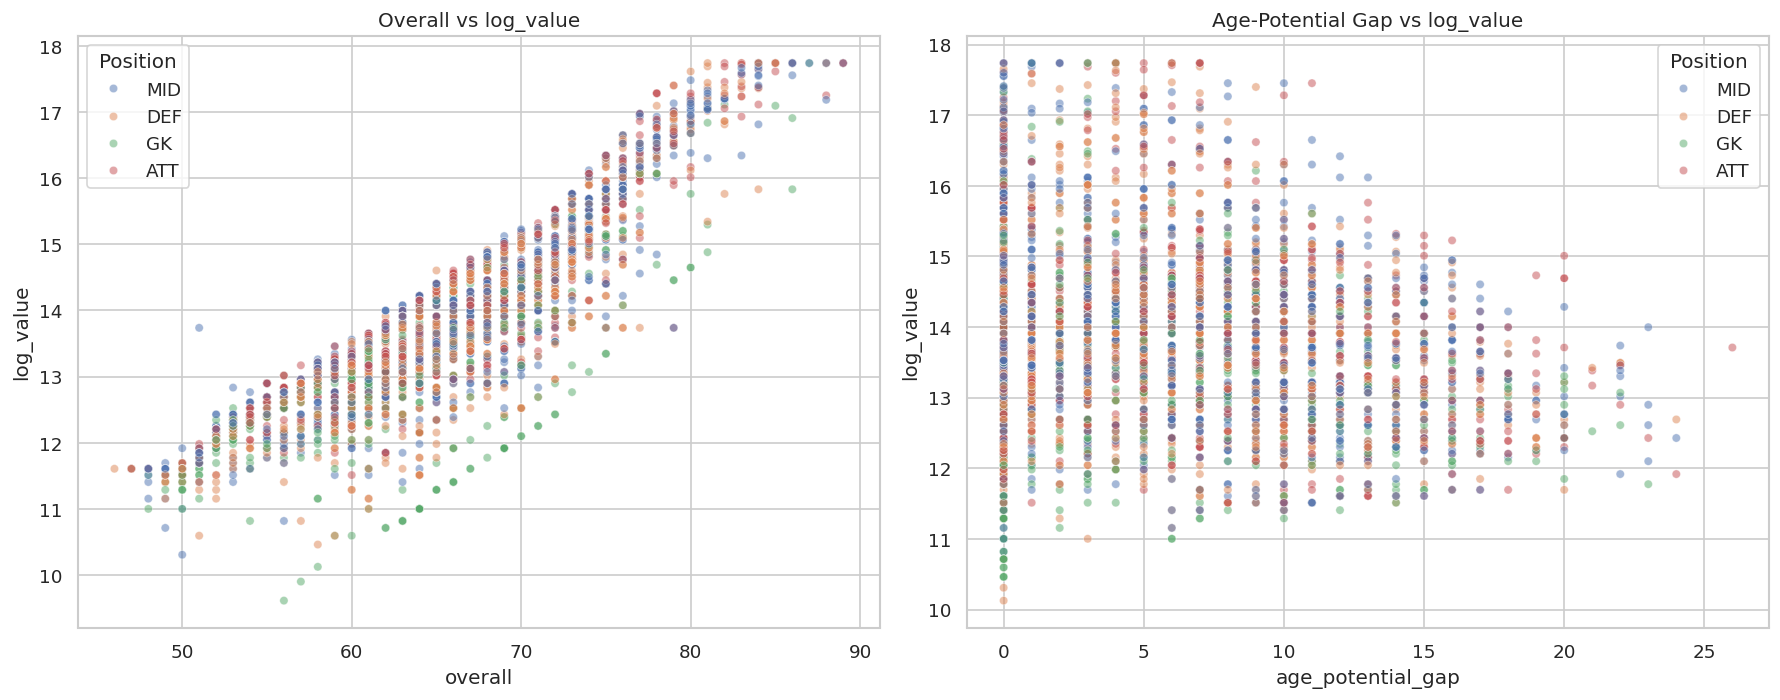

Saved: /home/adham/Desktop/DEPI-ML-PROJECT/ML/data/processed/figures/scatter_relationships.png


In [7]:
plot_df = players_clean[['overall', 'potential', 'age_potential_gap', 'position_group']].copy()
plot_df['log_value'] = model_ready['log_value']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    data=plot_df.sample(min(5000, len(plot_df)), random_state=42),
    x='overall',
    y='log_value',
    hue='position_group',
    alpha=0.5,
    s=25,
    ax=axes[0],
)
axes[0].set_title('Overall vs log_value')

sns.scatterplot(
    data=plot_df.sample(min(5000, len(plot_df)), random_state=7),
    x='age_potential_gap',
    y='log_value',
    hue='position_group',
    alpha=0.5,
    s=25,
    ax=axes[1],
)
axes[1].set_title('Age-Potential Gap vs log_value')

for ax in axes:
    ax.legend(title='Position', loc='best')

plt.tight_layout()
output_path = figures_dir / 'scatter_relationships.png'
plt.savefig(output_path, bbox_inches='tight')
plt.show()
print('Saved:', output_path)

## Notes

- Charts are saved to ML/data/processed/figures for reporting and sharing.
- Use this notebook for visual interpretation; keep ML/scripts/generate_eda_report.py for reproducible tabular checks.